# Week 9 Overview

This week will be a mix of data vizualization problems and . 

The first 5 problems are data cleaning and the final 4 problems are linear algebra. 

### Data Visualization

Data visualization is a key part of exploratory data analysis (EDA), a crucial initial step for understanding a dataset and preparing for statistical modeling.

Helps visually answer questions such as:
- what patterns are evident in the data?
- what variables are important?
- does the data have anomalies or outliers?

Data visualization is also used throughout the data analysis process to show results and convey information to stakeholders.

Typically, EDA uses `histograms` & `box plots` to visualize `distribution` of a single continuous variable. `Bar charts` & `scatterplots` are used for `bivariate analysis` - correlation between two variables.


#### Histograms

![histograms](https://raw.githubusercontent.com/brendenwest/cis276/main/images/histograms.png)

Display the distribution of a continuous variable.
- Useful for visualizing the shape, for identifying
patterns or trends, for detecting
outliers, skewness, or multimodality
- Divides data into equal-width intervals (`bins`)
- Height of each `bar` represents frequency or
`count` of observations
- Can also compare the distribution of two
or more variables


#### Box & Whisker Plots

A box plot can show how tightly data is grouped, how the data is skewed, and also the symmetry of data.

![image](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-2.png)

Display `median`, `quartiles`, and outliers.
- Useful for visualizing the distribution and spread.
- Box represents `interquartile range` (IQR)
- Line inside the box represents the median
- Whiskers extend from box to minimum and maximum values within 1.5 times the IQR from the box
- Values outside of this range are considered outliers and plotted as individual points


#### Scatterplots

Scatter (aka X-Y) plots show the relationship between two continuous variables. Also useful for identifying outlier data points.

![scatterplots](https://www.mathsisfun.com/data/images/correlation-examples.svg)



#### Bar Charts

Useful for visualizing distribution of `categorical` variables through relative size of bars.

-  One axis represents categories being compared
- Other axis represents frequency, count, or percentage of each category
- usually has space between bars to avoid confusion with histograms

![bar_chart](https://www.mathsisfun.com/data/images/bar-chart-movies.svg)


### Plotting with matplotlib

matplotlib is python package designed for creating (mostly two-dimensional) publication-quality plots.

It allows interactive plotting from the iPython shell or within Jupyter notebooks

matplotlib can export visualizations to  common vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.).

- plots & plot types
- title & labels
- legends
- subplots
- annotations
- saving plots

### Plotting with pandas

The pandas `plot()` method is a wrapper for matplotlib's pyplot.plot() and produces the same plots, but with simpler syntax for visualizing dataframes.
`.plot()` has several optional parameters. Most notably, the `kind` parameter  determines which kind of plot you’ll create (default is a `line` plot):

- "area" for area plots.
- "bar" for vertical bar charts.
- "barh" for horizontal bar charts.
- "box" for box plots.
- "hexbin" for hexbin plots.
- "hist" for histograms.
- "kde" for kernel density estimate charts.
- "density" an alias for "kde".
- "line" for line graphs.
- "pie" for pie charts.
- "scatter" for scatter plots.

### Plotting with seaborn

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn not only makes it easier than pandas to prepare a wider variety of plots, but supports enhancements for presentation-quality plots.

Seaborn supports several key types of plots:

- **relational** - show the relationship between two numeric variables. Includes scatter plots and line plots
- **categorical** - compare data in different categories
- **distribution** - examine how numeric data is distributed across a range of values. Types of distribution plots are histogram, kernel density estimate (KDE) plot, and empirical cumulative distribution function (ECDF) plot
- **predictive** - plots that are designed for predictive analysis, such as for linear regression models.

#### Seaborn styles

`set_style(style)`
Sets the background style with one of these values: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks` (the default). This style stays in effect until it is changed by another set_style() call.
#### General vs. specific methods

You can create Seaborn plots using the general `relplot()` command, which expects a `kind` parameter.

Alternatively, you can use a specific method - e.g. `lineplot()`, which does not require a `kind` parameter.

The two approaches mostly produce the same result, but the the general methods let you create plots with subplots, while the specific methods don’t.

So the general methods return a `FacetGrid` object that contains an `Axes` object for each subplot. The specific methods return an `Axes` object.

#### Basic Seaborn plot parameters

- data - the DataFrame of data to plot
- kind - the type of plot (general plots only)
- x, y - data columns for the x- and y-axis
- hue -  the column that determines categories to plot, with different color for each category
- palette -  color pallette for the plot
- height - The height of the plot in inches with a default of 5. (general plots only)
- aspect - the ratio of width to height (general plots only)
- legend - options for how the legend will be drawn: `auto` (the default), `brief`, `full`, and `False`. (general plots only)

#### Creating subplots

- By default, x and y labels are shared by subplots
- subplots get their title from the category label

#### Modifying plot features

The `Axes` object that provides methods for enhancing a plot.

#### Saving plots

Seaborn plots can be saved to PNG, SVG, or PDF files. The approach is slightly different for plots created with general or specific methods.

- **General method** - assign the plot's FacetGrid object to a variable and then use the `savefig()` method of the FacetGrid object
- **Specific method** - call the `get_figure()` method on the Axes object  returned by the lineplot() method, then chain go the `savefig()` method

# Data Visualization Problems

For the problems this week we are going to go a step deeper and start to ask questions about our data. 

In [3]:
import pandas as pd
import seaborn as sns

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::disability-and-health-insurance-seattle-neighborhoods/about
dis_health_df = pd.read_csv('seattle_data/disability_health_insurance_Neighborhoods.csv')
dis_health_df.columns = [i.replace(" ", "_") for i in dis_health_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::poverty-and-employment-status-seattle-neighborhoods/about
income_df = pd.read_csv('seattle_data/incomes_Neighborhoods.csv')
income_df.columns = [i.replace(" ", "_") for i in income_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::incomes-occupations-and-earnings-seattle-neighborhoods/about
poverty_df = pd.read_csv('seattle_data/poverty_Neighborhoods.csv')
poverty_df.columns = [i.replace(" ", "_") for i in poverty_df.columns]

## Problem 1: Asking Questions (10 pts)

Take 5 minutes to look through the above data sources as pose 5 analytical questions you might want to ask with that data. By analytical I mean question will drive informative analysis. For example:

**Good Question**: Is there relationship between health insurance coverage and disability?

**Bad Question**: How many neighboorhoods are there?

The second question is the type of question that is is good to ask when processing the data to make sure you processed it correctly but it doesn't give you insights into the data.

At least two of the questions must involve data from at least two of the datasets.

In class you will share your questions with your group and as a group you will pick two questions to focus on for analysis in class. On your own this week you will answer the rest of your questions.

**Grading**
You will receive 2 points per question. One point for forming a question the other for it being a analytical question. 

In [5]:
print("Income DF columns:")
print(list(income_df.columns))
print("\nPoverty DF columns:")
print(list(poverty_df.columns))
print("\nDisability DF columns:")
print(list(dis_health_df.columns))

Income DF columns:
['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type', 'Neighborhood_Subtype', 'ACS_Vinatage', 'Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars)', 'Total_Population', 'Total_Households', 'Household_Income_Less_than_$10,000', 'Household_Income_$10,000_to_$14,999', 'Household_Income_$15,000_to_$24,999', 'Household_Income_$25,000_to_$34,999', 'Household_Income_$35,000_to_$49,999', 'Household_Income_$50,000_to_$74,999', 'Household_Income_$75,000_to_$99,999', 'Household_Income_$100,000_to_$149,999', 'Household_Income_$150,000_to_$199,999', 'Household_Income_$200,000_or_more', 'Total_Family_Households', 'Family_Household_Income_Less_than_$10,000', 'Family_Household_Income_$10,000_to_$14,999', 'Family_Household_Income_$15,000_to_$24,999', 'Family_Household_Income_$25,000_to_$34,999', 'Family_Household_Income_$35,000_to_$49,999', 'Family_Household_Income_$50,000_to_$74,999', 'Family_Household_Income_$75,000_to_$99,999', 'Family_Househol

## Problem 2: Data Cleaning and Merging (10 pts)

Take a few minutes to prepare your data for analysis. You can decide what preparation is required but you must at least perform two of the following to receive credit. You might find that you start to create a graph and then need to prepare the data better (i.e. remove an outlier) that is expected.

1. Clean up the column names.
2. Merge dataframes together. 
3. Fill in null values.
4. Removing outliers. 
5. Change the shape of the data (We will learn aggregations next week but if you know how feel free to use them).
6. Any other preparation required to answer your questions.

For each preparation step add a comment to explain why you did that step. 

**Grading** You will receive 5 points for the first two data prep steps you perform. 2 point will be for the comment and then 3 points will be for accurately performing the prep. 

In [6]:
# Merge income and poverty data on neighborhood name
# This allows us to compare income and poverty rates in the same analysis
merged_df = income_df.merge(poverty_df, left_on='Neighborhood_Name', right_on='Neighborhood_Name', how='inner', suffixes=('_income', '_poverty'))

# Merge with disability/health data
# This consolidates all datasets so we can analyze relationships across multiple variables
full_data = merged_df.merge(dis_health_df, left_on='Neighborhood_Name', right_on='Neighborhood_Name', how='inner', suffixes=('', '_dis'))

# Calculate poverty percentage
# Null values are excluded by calculating percentages only where data exists
full_data['Poverty_%'] = (full_data['Population_20_to_64_years_below_poverty'] / full_data['Population_20_to_64_years_for_whom_poverty_status_is_determined'] * 100).fillna(0)

# Calculate disability percentage (18-64 years old)
full_data['Disability_%'] = (full_data['Population_18_to_64_years_with_a_Disability'] / full_data['Population_18_to_64_years'] * 100).fillna(0)

# Calculate health insurance coverage percentage
# Count those with insurance by summing age groups
with_insurance = (full_data['Population_under_19_years_with_Health_Insurance'] + 
                  full_data['Population_19_to_34_years_with_Health_Insurance'] +
                  full_data['Population_35_to_64_years_with_Health_Insurance'] +
                  full_data['Population_65_years_and_Over_with_Health_Insurance'])
total_pop = full_data['Population_Civilian_Noninstitutionalized']
full_data['With_Health_Insurance_%'] = (with_insurance / total_pop * 100).fillna(0)

# Use aggregate income as median household income proxy
full_data['Median_Household_Income'] = full_data['Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars)'] / full_data['Total_Households']

# Calculate employment percentage
full_data['Employed_%'] = (full_data['Population_20_to_64_years_employed'] / full_data['Population_20_to_64_years_for_whom_poverty_status_is_determined'] * 100).fillna(0)

print(f"Merged dataset shape: {full_data.shape}")
print(f"\nKey columns created: Poverty_%, Disability_%, With_Health_Insurance_%, Median_Household_Income, Employed_%")

Merged dataset shape: (140, 145)

Key columns created: Poverty_%, Disability_%, With_Health_Insurance_%, Median_Household_Income, Employed_%


C:\Users\mohit\AppData\Local\Temp\ipykernel_22768\920888801.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['Poverty_%'] = (full_data['Population_20_to_64_years_below_poverty'] / full_data['Population_20_to_64_years_for_whom_poverty_status_is_determined'] * 100).fillna(0)
C:\Users\mohit\AppData\Local\Temp\ipykernel_22768\920888801.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['Disability_%'] = (full_data['Population_18_to_64_years_with_a_Disability'] / full_data['Population_18_to_64_years'] * 100)

## Problem 3: Question 1 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [ ]:
### Question 1: Is there a relationship between disability percentage and health insurance coverage?

**Findings:** By examining the relationship between disability rates and health insurance coverage across neighborhoods, we can identify whether neighborhoods with higher disability rates have lower insurance coverage rates or other patterns in healthcare access.

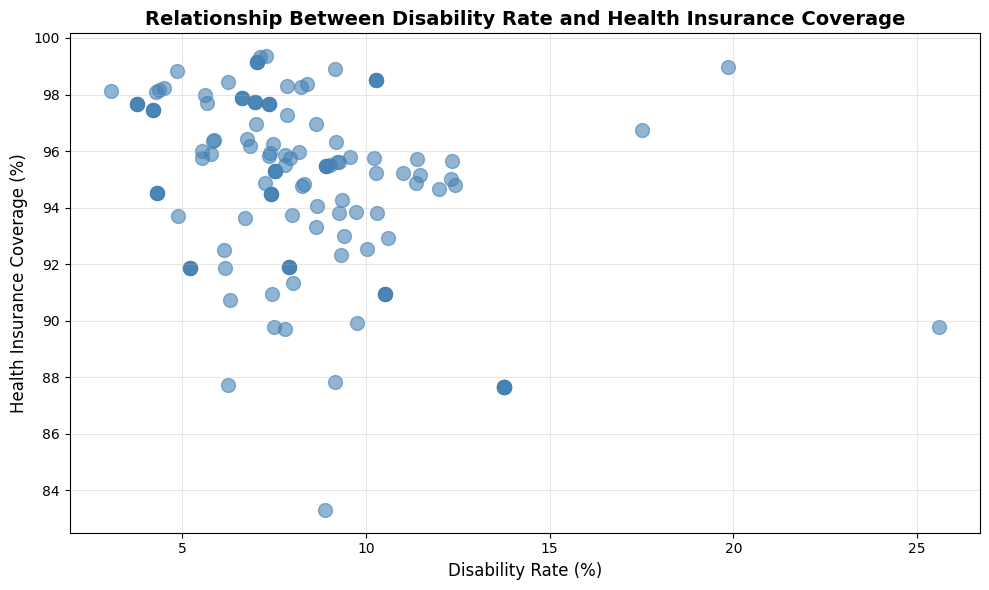

In [7]:
import matplotlib.pyplot as plt

# Select relevant columns and drop any rows with missing values
plot_data = full_data[['Disability_%', 'With_Health_Insurance_%']].dropna()

# Create scatterplot - selected because it shows relationship between two continuous variables
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data['Disability_%'], plot_data['With_Health_Insurance_%'], s=100, alpha=0.6, color='steelblue')

# Modification 1: Add a descriptive title to clearly convey the analysis
ax.set_title('Relationship Between Disability Rate and Health Insurance Coverage', fontsize=14, fontweight='bold')

# Modification 2: Add appropriate axis labels with percentage signs for clarity
ax.set_xlabel('Disability Rate (%)', fontsize=12)
ax.set_ylabel('Health Insurance Coverage (%)', fontsize=12)

# Add grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Select relevant columns and drop any rows with missing values
plot_data = full_data[['Disability_%', 'With_Health_Insurance_%']].dropna()

# Create scatterplot - selected because it shows relationship between two continuous variables
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data['Disability_%'], plot_data['With_Health_Insurance_%'], s=100, alpha=0.6, color='steelblue')

# Modification 1: Add a descriptive title to clearly convey the analysis
ax.set_title('Relationship Between Disability Rate and Health Insurance Coverage', fontsize=14, fontweight='bold')

# Modification 2: Add appropriate axis labels with percentage signs for clarity
ax.set_xlabel('Disability Rate (%)', fontsize=12)
ax.set_ylabel('Health Insurance Coverage (%)', fontsize=12)

# Add grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 4: Question 2 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [ ]:
### Question 2: How does median household income correlate with poverty rates?

**Findings:** Exploring the relationship between household income and poverty rates reveals whether neighborhoods with higher median incomes tend to have lower poverty rates, helping us understand economic disparities across Seattle neighborhoods.

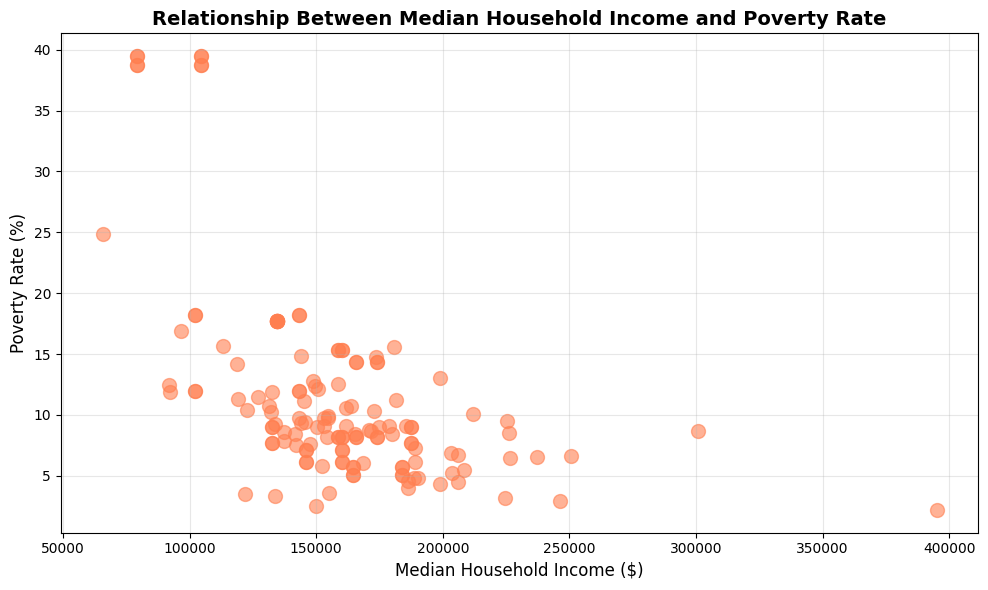

In [8]:
import matplotlib.pyplot as plt

# Select income and poverty columns, drop missing values
plot_data2 = full_data[['Median_Household_Income', 'Poverty_%']].dropna()

# Create scatterplot to show relationship between two continuous variables
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data2['Median_Household_Income'], plot_data2['Poverty_%'], s=100, alpha=0.6, color='coral')

# Modification 1: Add descriptive title
ax.set_title('Relationship Between Median Household Income and Poverty Rate', fontsize=14, fontweight='bold')

# Modification 2: Format income axis with proper labeling and use color to highlight data
ax.set_xlabel('Median Household Income ($)', fontsize=12)
ax.set_ylabel('Poverty Rate (%)', fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 5: Question 3 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [ ]:
### Question 3: Which neighborhoods have the highest disability rates and lowest health insurance coverage?

**Findings:** By examining the distribution of disability rates and health insurance coverage separately, we can identify neighborhoods with the greatest need for healthcare resources and support services.

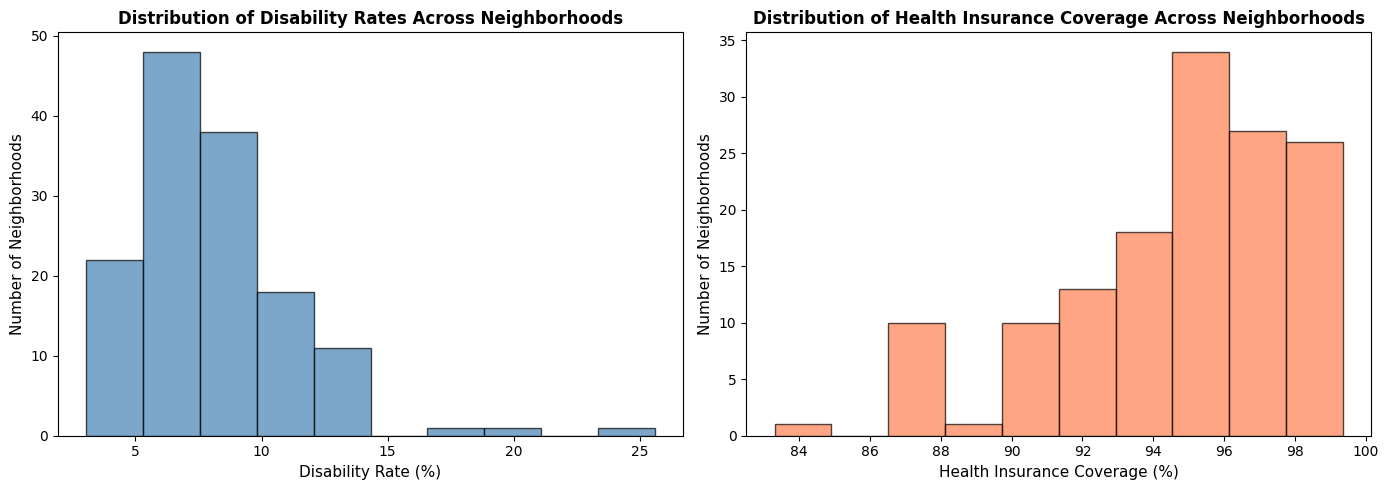

In [9]:
import matplotlib.pyplot as plt

# Create histograms to show distribution of disability rates and insurance coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for disability rates
axes[0].hist(full_data['Disability_%'].dropna(), bins=10, color='steelblue', edgecolor='black', alpha=0.7)

# Modification 1: Add descriptive title and labels
axes[0].set_title('Distribution of Disability Rates Across Neighborhoods', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Disability Rate (%)', fontsize=11)
axes[0].set_ylabel('Number of Neighborhoods', fontsize=11)

# Histogram for health insurance coverage
axes[1].hist(full_data['With_Health_Insurance_%'].dropna(), bins=10, color='coral', edgecolor='black', alpha=0.7)

# Modification 2: Use different colors to distinguish the distributions and improve visual clarity
axes[1].set_title('Distribution of Health Insurance Coverage Across Neighborhoods', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Health Insurance Coverage (%)', fontsize=11)
axes[1].set_ylabel('Number of Neighborhoods', fontsize=11)

plt.tight_layout()
plt.show()

## Problem 6: Question 4 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [ ]:
### Question 4: Is there a relationship between income levels and disability rates?

**Findings:** Analyzing the relationship between income and disability provides insight into whether lower-income neighborhoods tend to have higher disability rates or other socioeconomic patterns related to disability.

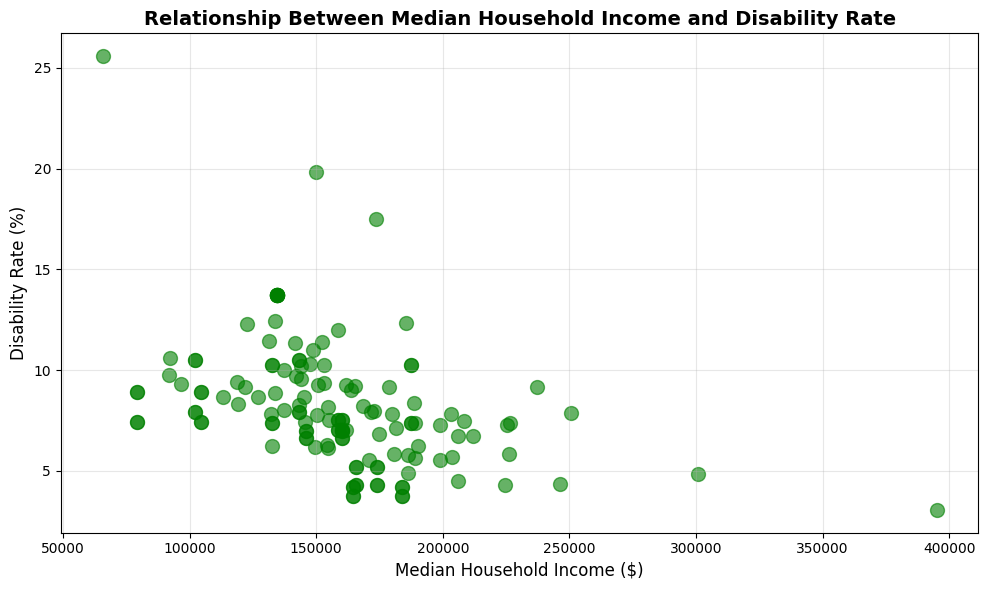

In [10]:
import matplotlib.pyplot as plt

# Select income and disability columns, drop missing values
plot_data4 = full_data[['Median_Household_Income', 'Disability_%']].dropna()

# Create scatterplot to show relationship between income and disability
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data4['Median_Household_Income'], plot_data4['Disability_%'], s=100, alpha=0.6, color='green')

# Modification 1: Add descriptive title
ax.set_title('Relationship Between Median Household Income and Disability Rate', fontsize=14, fontweight='bold')

# Modification 2: Format axes clearly with appropriate labels for economic data
ax.set_xlabel('Median Household Income ($)', fontsize=12)
ax.set_ylabel('Disability Rate (%)', fontsize=12)

# Add grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 7: Question 5 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [ ]:
### Question 5: Do neighborhoods with higher poverty rates have lower health insurance coverage?

**Findings:** This analysis examines whether poverty and health insurance coverage are inversely related, helping identify communities where economic hardship may impact healthcare access.

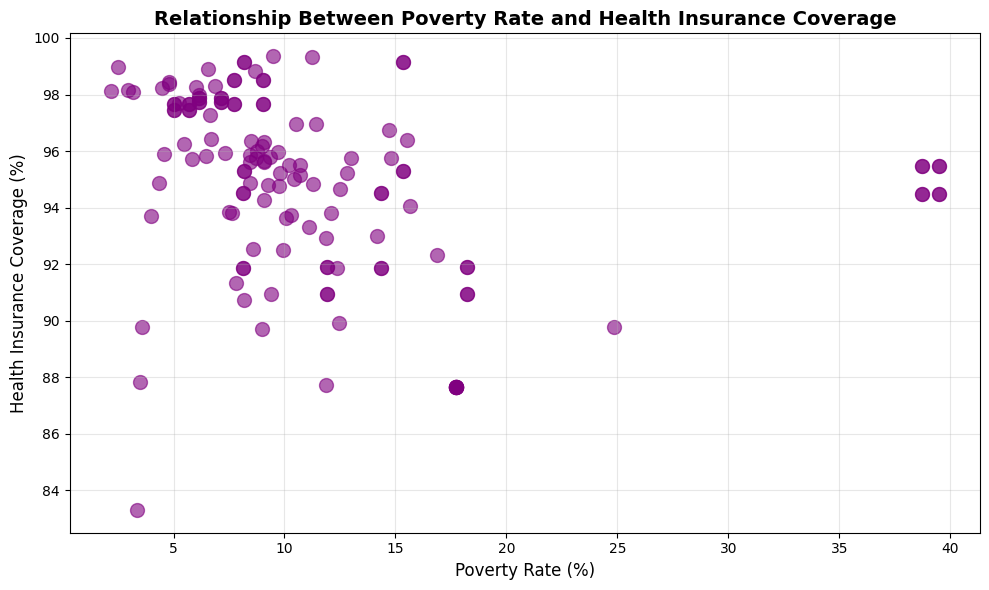

In [11]:
import matplotlib.pyplot as plt

# Select poverty and health insurance columns, drop missing values
plot_data5 = full_data[['Poverty_%', 'With_Health_Insurance_%']].dropna()

# Create scatterplot to show relationship between poverty and insurance coverage
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data5['Poverty_%'], plot_data5['With_Health_Insurance_%'], s=100, alpha=0.6, color='purple')

# Modification 1: Add descriptive title
ax.set_title('Relationship Between Poverty Rate and Health Insurance Coverage', fontsize=14, fontweight='bold')

# Modification 2: Use descriptive labels and color to emphasize the inverse relationship
ax.set_xlabel('Poverty Rate (%)', fontsize=12)
ax.set_ylabel('Health Insurance Coverage (%)', fontsize=12)

# Add grid for easier pattern detection
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 8 (10pts)
Pick 5 columns in the datasets above and create a covariance by completing the following steps:

1. Mean center all columns. You can use panda's mean function for this. 
2. Create a covariance matrix as follows:
$$ C = X^T X \dfrac{1}{n-1}$$
3. You should save this to a dateframe called `cov_df` to be used in the next problem. 
4. Output the results of `cov_df` and visually check your results against [DataFrame.cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html). The numbers should match. 

In [12]:
import numpy as np

# Select 5 columns from the data
selected_cols = ['Disability_%', 'With_Health_Insurance_%', 'Median_Household_Income', 'Poverty_%', 'Employed_%']
X = full_data[selected_cols].dropna()

# Mean center all columns
X_centered = X - X.mean()

# Calculate covariance matrix: C = X^T X / (n-1)
n = X_centered.shape[0]
cov_df = pd.DataFrame(
    (X_centered.T @ X_centered) / (n - 1),
    index=selected_cols,
    columns=selected_cols
)

print("Our Covariance Matrix:")
print(cov_df)
print("\n" + "="*50)

# Compare with pandas built-in covariance
pandas_cov = X.cov()
print("\nPandas Covariance Matrix:")
print(pandas_cov)
print("\n" + "="*50)

# Check if they match
print("\nDifference (should be close to 0):")
print(np.abs(cov_df - pandas_cov).max().max())

Our Covariance Matrix:
                         Disability_%  With_Health_Insurance_%  \
Disability_%                10.042440                -4.017880   
With_Health_Insurance_%     -4.017880                10.857084   
Median_Household_Income -58541.540685             61944.569832   
Poverty_%                    6.590770                -6.861619   
Employed_%                  -7.142192                 4.673899   

                         Median_Household_Income      Poverty_%    Employed_%  
Disability_%                       -5.854154e+04       6.590770     -7.142192  
With_Health_Insurance_%             6.194457e+04      -6.861619      4.673899  
Median_Household_Income             1.764611e+09 -192750.229891  90824.586151  
Poverty_%                          -1.927502e+05      64.194861    -39.835845  
Employed_%                          9.082459e+04     -39.835845     38.224033  


Pandas Covariance Matrix:
                         Disability_%  With_Health_Insurance_%  \
Disabi

## Problem 9 (10pts)

Next you will take the `cov_df` and create a correlation matrix from it. The formula for this is

$$ R = SCS $$

Where $C$ is the covariance matrix `cov_df`, and $S$ is a diagonal matrix of reciprocated standard deviations per variable (that is, the ith diagonal is $\dfrac{1}{\sigma_i}$ where $\sigma_i$ is the standard deviation of variable i). You can use panda's standard deviation function to create $S$. 

Once you have created the correlation matrix visually compare it to [np.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)

In [13]:
import numpy as np

# Calculate standard deviations for each column
std_devs = X.std()

# Create S as a diagonal matrix of 1/standard_deviation
S = np.diag(1 / std_devs.values)

# Calculate correlation matrix: R = S C S
C = cov_df.values
R = S @ C @ S

# Convert to dataframe for easier comparison
corr_df = pd.DataFrame(
    R,
    index=selected_cols,
    columns=selected_cols
)

print("Our Correlation Matrix (R = SCS):")
print(corr_df)
print("\n" + "="*50)

# Compare with numpy.corrcoef
# Note: np.corrcoef expects each row to be a variable
numpy_corr = np.corrcoef(X.T)
numpy_corr_df = pd.DataFrame(
    numpy_corr,
    index=selected_cols,
    columns=selected_cols
)
print("\nNumPy Correlation Matrix:")
print(numpy_corr_df)
print("\n" + "="*50)

# Check if they match
print("\nDifference (should be close to 0):")
print(np.abs(corr_df - numpy_corr_df).max().max())

Our Correlation Matrix (R = SCS):
                         Disability_%  With_Health_Insurance_%  \
Disability_%                 1.000000                -0.384787   
With_Health_Insurance_%     -0.384787                 1.000000   
Median_Household_Income     -0.439764                 0.447530   
Poverty_%                    0.259577                -0.259908   
Employed_%                  -0.364539                 0.229432   

                         Median_Household_Income  Poverty_%  Employed_%  
Disability_%                           -0.439764   0.259577   -0.364539  
With_Health_Insurance_%                 0.447530  -0.259908    0.229432  
Median_Household_Income                 1.000000  -0.572691    0.349712  
Poverty_%                              -0.572691   1.000000   -0.804184  
Employed_%                              0.349712  -0.804184    1.000000  


NumPy Correlation Matrix:
                         Disability_%  With_Health_Insurance_%  \
Disability_%                 1.